<a href="https://colab.research.google.com/github/francji1/01NAEX/blob/main/code/01NAEX_Ex02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01NAEX - Exercise 02: Single-factor experiments and ANOVA

Data and exercises come from D. C. Montgomery: *Design and Analysis of Experiments*, 8th edition, Chapter 3.
Problem numbers follow the 8th edition.

## Learning goals

* Fit the one-way fixed-effects model in `statsmodels`, read the ANOVA table and test $H_0: \mu_1 = \dots = \mu_a$.
* Check the model assumptions with residual plots and formal tests (normality, equal variances, independence).
* Compare treatment means after a significant $F$-test: Fisher's LSD, Tukey's HSD and $p$-value adjustments, and understand what each one controls.
* Compute confidence intervals for treatment means and their differences.
* Determine the sample size (replicates per level) needed to detect a given difference with a given power.


## Example from the lecture: plasma etch rate experiment

Lecture 2 analysed the plasma etching experiment (Montgomery, Example 3.1): the etch rate of a wafer at four levels of RF power
(160, 180, 200, 220 W), five replicates per level, 20 runs in random order. We repeat the analysis in Python:
- explore and visualise the raw data,
- fit the one-way ANOVA model (and, for comparison, a model with the run index as a second factor),
- inspect the residuals and test the assumptions,
- compare the treatment means (Fisher's LSD, Tukey's HSD), and
- evaluate the power of the design for several numbers of replicates.

In [1]:
# Core scientific Python stack for the example
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import FTestAnovaPower
from statsmodels.graphics.gofplots import qqplot

sns.set_theme(style="whitegrid")
np.set_printoptions(suppress=True)


In [2]:
# Load the plasma etch rate data used in the lecture example
ETCH_URL = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/etchrate.txt"
etch_rate = pd.read_csv(ETCH_URL, sep=r"\s+")

# Create categorical views that will be useful for the formulas
etch_rate = etch_rate.assign(
    Power=etch_rate["RF"].astype("category"),
    Run=etch_rate["run"].astype("category")
)

print("Rows, columns:", etch_rate.shape)
display(etch_rate.head())
etch_rate.describe(include="all")


Rows, columns: (20, 5)


,RF,run,rate,Power,Run
0,160,1,575,160,1
1,160,2,542,160,2
2,160,3,530,160,3
3,160,4,539,160,4
4,160,5,570,160,5


,RF,run,rate,Power,Run
count,20.000000,20.000000,20.000000,20.0,20.0
unique,NaN,NaN,NaN,4.0,5.0
top,NaN,NaN,NaN,160.0,1.0
freq,NaN,NaN,NaN,5.0,4.0
mean,190.000000,3.000000,617.750000,NaN,NaN
std,22.941573,1.450953,61.648302,NaN,NaN
min,160.000000,1.000000,530.000000,NaN,NaN
25%,175.000000,2.000000,573.750000,NaN,NaN
50%,190.000000,3.000000,605.000000,NaN,NaN
75%,205.000000,4.000000,659.500000,NaN,NaN


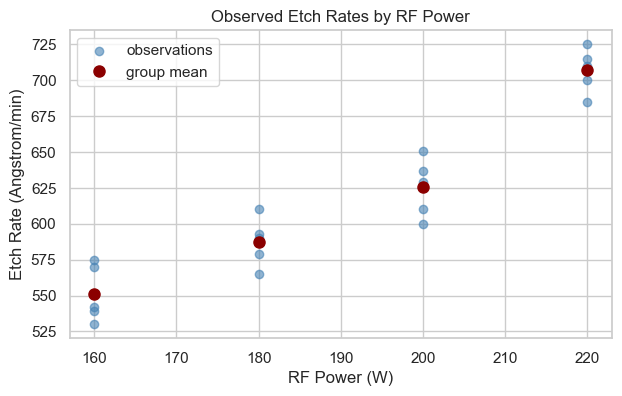

In [3]:
# Visual summary: scatter of observed rates with group means highlighted
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(etch_rate["RF"], etch_rate["rate"], color="steelblue", alpha=0.6, label="observations")
(
    etch_rate.groupby("RF")["rate"].mean()
    .plot(marker="o", color="darkred", linewidth=0, markersize=8, label="group mean", ax=ax)
)
ax.set_xlabel("RF Power (W)")
ax.set_ylabel("Etch Rate (Angstrom/min)")
ax.set_title("Observed Etch Rates by RF Power")
ax.legend()
plt.show()


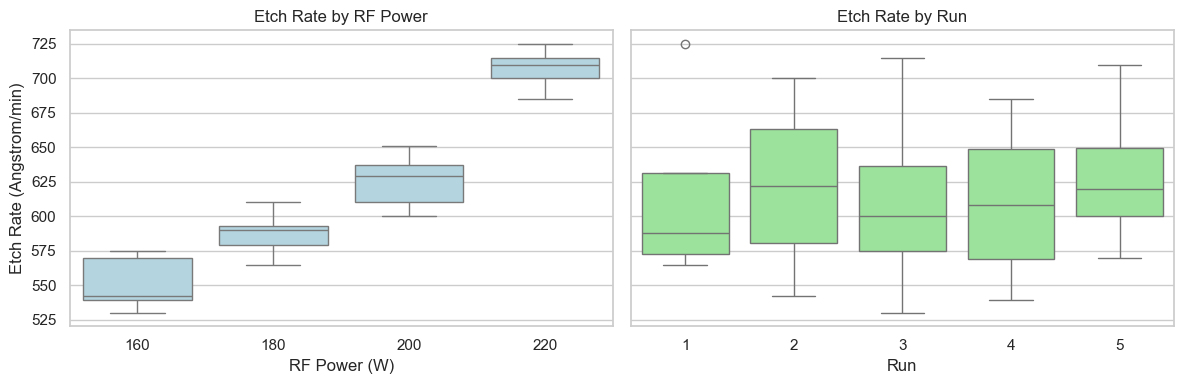

In [4]:
# Boxplots by RF power and by run index (the run index is not a designed block, it only shows that there is no run-to-run drift)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.boxplot(data=etch_rate, x="Power", y="rate", ax=axes[0], color="lightblue")
axes[0].set_title("Etch Rate by RF Power")
axes[0].set_xlabel("RF Power (W)")
axes[0].set_ylabel("Etch Rate (Angstrom/min)")

sns.boxplot(data=etch_rate, x="Run", y="rate", ax=axes[1], color="lightgreen")
axes[1].set_title("Etch Rate by Run")
axes[1].set_xlabel("Run")

plt.tight_layout()
plt.show()


In [5]:
# Fit single-factor and two-factor ANOVA models used in the lecture
model_power = ols("rate ~ C(Power)", data=etch_rate).fit()
model_power_no_intercept = ols("rate ~ C(Power) - 1", data=etch_rate).fit()
model_power_run = ols("rate ~ C(Power) + C(Run)", data=etch_rate).fit()

print(model_power.summary())


                            OLS Regression Results                            
Dep. Variable:                   rate   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     66.80
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           2.88e-09
Time:                        14:43:13   Log-Likelihood:                -84.250
No. Observations:                  20   AIC:                             176.5
Df Residuals:                      16   BIC:                             180.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         551.2000      8.169     

In [6]:
# ANOVA tables (type II sums of squares) for both models
anova_power = sm.stats.anova_lm(model_power, typ=2)
anova_power_run = sm.stats.anova_lm(model_power_run, typ=2)

display(anova_power)
display(anova_power_run)

# Direct comparison of the nested models (Power-only vs Power + Run)
display(sm.stats.anova_lm(model_power, model_power_run))


,sum_sq,df,F,PR(>F)
C(Power),66870.55,3.0,66.797073,2.882866e-09
Residual,5339.20,16.0,NaN,NaN


,sum_sq,df,F,PR(>F)
C(Power),66870.55,3.0,62.369063,1.368674e-07
C(Run),1050.50,4.0,0.734838,5.856737e-01
Residual,4288.70,12.0,NaN,NaN


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,16.0,5339.2,0.0,NaN,NaN,NaN
1,12.0,4288.7,4.0,1050.5,0.734838,0.585674


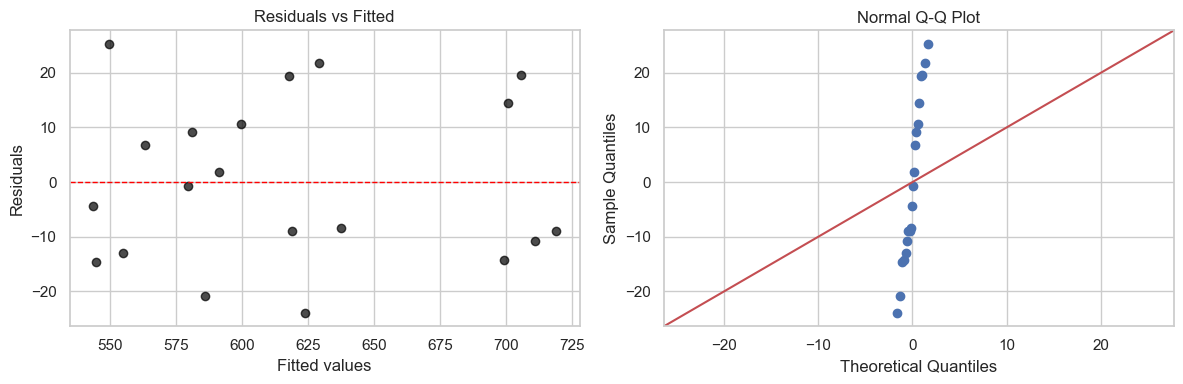

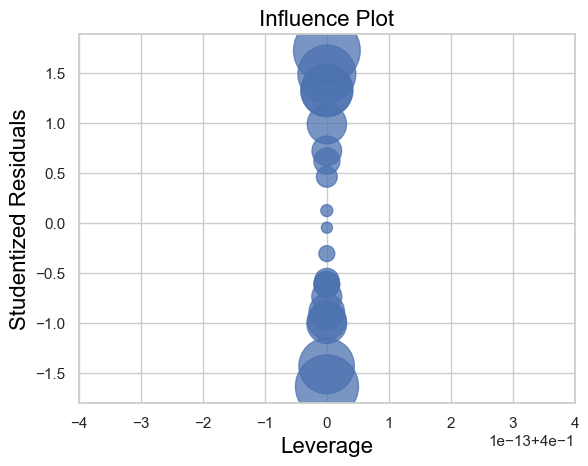

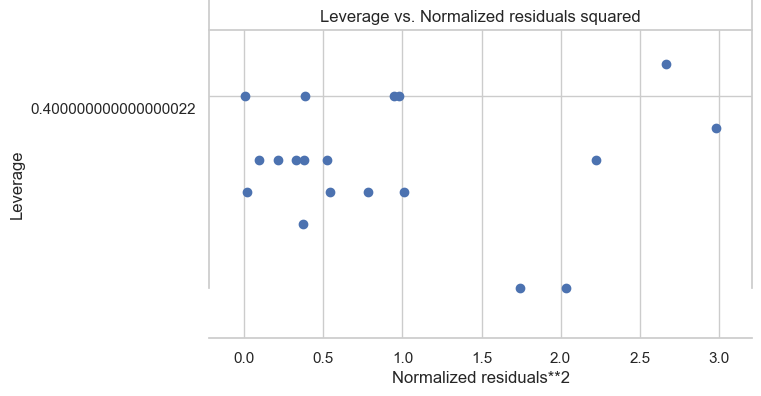

In [7]:
# Regression diagnostics mirroring the lecture content
residuals = model_power_run.resid
fitted = model_power_run.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(fitted, residuals, color="black", alpha=0.7)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

qqplot(residuals, line="45", ax=axes[1])
axes[1].set_title("Normal Q-Q Plot")

plt.tight_layout()
plt.show()

influence = OLSInfluence(model_power_run)
fig = influence.plot_influence(figsize=(8, 6))
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sm.graphics.plot_leverage_resid2(model_power_run, ax=ax)
plt.show()


In [8]:
# Formal tests from the lecture: normality of residuals, equal variances across power levels, heteroscedasticity, autocorrelation
s_w, s_p = stats.shapiro(residuals)
levene_stat, levene_p = stats.levene(
    *[group["rate"].to_numpy(dtype=float) for _, group in etch_rate.groupby("Power", observed=True)]
)
bartlett_stat, bartlett_p = stats.bartlett(
    *[group["rate"].to_numpy(dtype=float) for _, group in etch_rate.groupby("Power", observed=True)]
)

bp_stat, bp_p, _, _ = het_breuschpagan(residuals, model_power_run.model.exog)
dw_stat = sm.stats.durbin_watson(residuals)

print(f"Shapiro-Wilk (residuals) W = {s_w:.4f}, p-value: {s_p:.3f}")
print(f"Levene (Brown-Forsythe) F = {levene_stat:.4f}, p-value: {levene_p:.3f}")
print(f"Bartlett K^2 = {bartlett_stat:.4f}, p-value: {bartlett_p:.3f}")
print(f"Breusch-Pagan p:     {bp_p:.3f}")
print(f"Durbin-Watson stat:  {dw_stat:.3f}")


Shapiro-Wilk (residuals) W = 0.9465, p-value: 0.317
Levene (Brown-Forsythe) F = 0.1959, p-value: 0.898
Bartlett K^2 = 0.4335, p-value: 0.933
Breusch-Pagan p:     0.038
Durbin-Watson stat:  2.854


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
   160    180     36.2 0.0294   3.1456  69.2544   True
   160    200     74.2    0.0  41.1456 107.2544   True
   160    220    155.8    0.0 122.7456 188.8544   True
   180    200     38.0 0.0216   4.9456  71.0544   True
   180    220    119.6    0.0  86.5456 152.6544   True
   200    220     81.6    0.0  48.5456 114.6544   True
------------------------------------------------------


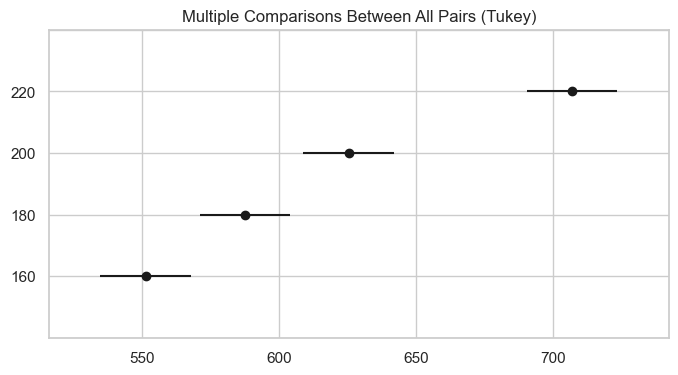

In [9]:
# Tukey HSD multiple comparisons (as demonstrated in the lecture)
tukey = pairwise_tukeyhsd(endog=etch_rate["rate"], groups=etch_rate["Power"], alpha=0.05)
print(tukey)
fig = tukey.plot_simultaneous(figsize=(8, 4))
plt.show()


In [10]:
# Fisher's LSD for the Power-only model (the lecture uses MSE = 333.7 with 16 error df, LSD = 24.49)
means = etch_rate.groupby("Power", observed=True)["rate"].mean()
counts = etch_rate.groupby("Power", observed=True)["rate"].count()
mse = anova_power.loc["Residual", "sum_sq"] / anova_power.loc["Residual", "df"]
df_error = anova_power.loc["Residual", "df"]

alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df_error)
lsd = t_crit * np.sqrt(2 * mse / counts.iloc[0])          # balanced design: all n_i equal
print(f"MSE = {mse:.1f}, error df = {df_error:.0f}, t = {t_crit:.3f}, LSD (alpha = {alpha}) = {lsd:.2f}")
print("Group means (Angstrom/min):"); print(means)

# all pairwise comparisons: |difference| > LSD means the two means differ
rows = []
levels = list(means.index)
for i in range(len(levels)):
    for j in range(i + 1, len(levels)):
        diff = means.iloc[j] - means.iloc[i]
        rows.append({"pair": f"{levels[j]} - {levels[i]}", "difference": diff, "|diff| > LSD": abs(diff) > lsd})
display(pd.DataFrame(rows))

MSE = 333.7, error df = 16, t = 2.120, LSD (alpha = 0.05) = 24.49
Group means (Angstrom/min):
Power
160    551.2
180    587.4
200    625.4
220    707.0
Name: rate, dtype: float64


,pair,difference,|diff| > LSD
0,180 - 160,36.2,True
1,200 - 160,74.2,True
2,220 - 160,155.8,True
3,200 - 180,38.0,True
4,220 - 180,119.6,True
5,220 - 200,81.6,True


,n per group,Phi^2,power
0,4,4.500,0.606
1,5,5.625,0.805
2,6,6.750,0.915
3,7,7.875,0.967
4,8,9.000,0.988
5,9,10.125,0.996
6,10,11.250,0.999


Cohen's f = 1.061; replicates per level for power 0.9: 6 (exact 5.81)


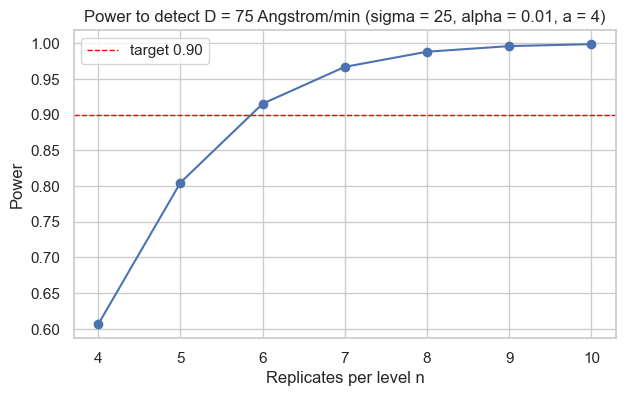

In [11]:
# Sample size: power of the one-way ANOVA F-test for n replicates per level (lecture: D = 75, sigma = 25, alpha = 0.01)
power_analysis = FTestAnovaPower()
alpha = 0.01
sigma = 25          # pilot estimate of the standard deviation
max_diff = 75       # we want to detect two means at least D = 75 Angstrom/min apart
k = 4               # number of levels

# Least favourable configuration: two means D apart, the rest at the overall mean ->
# sum (mu_i - mu)^2 = D^2 / 2, Cohen's f = sqrt(sum (mu_i - mu)^2 / k) / sigma, Phi^2 = n * D^2 / (2 * k * sigma^2)
cohen_f = (max_diff / sigma) * np.sqrt(1 / (2 * k))

sample_sizes = np.arange(4, 11)
power_values = [power_analysis.power(effect_size=cohen_f, nobs=n * k, alpha=alpha, k_groups=k) for n in sample_sizes]
power_df = pd.DataFrame({"n per group": sample_sizes, "Phi^2": sample_sizes * max_diff**2 / (2 * k * sigma**2), "power": power_values})
display(power_df.round(3))

n_needed = power_analysis.solve_power(effect_size=cohen_f, alpha=alpha, power=0.9, k_groups=k) / k
print(f"Cohen's f = {cohen_f:.3f}; replicates per level for power 0.9: {np.ceil(n_needed):.0f} (exact {n_needed:.2f})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sample_sizes, power_values, marker="o")
ax.set_xlabel("Replicates per level n"); ax.set_ylabel("Power")
ax.set_title("Power to detect D = 75 Angstrom/min (sigma = 25, alpha = 0.01, a = 4)")
ax.axhline(0.9, color="red", linestyle="--", linewidth=1, label="target 0.90")
ax.legend(); plt.show()

## Assignment

* Run the notebook above and make sure you understand each step.
* Solve the following problems from Montgomery, *Design and Analysis of Experiments* (8th edition), Chapter 3: **3.7, 3.8, 3.9, 3.10, 3.18 and 3.19**. Start in class and finish at home.
* For every test state the hypotheses, report the test statistic, its $p$-value and your decision; for comparisons of means say which procedure you use and why; check the assumptions with residual plots; end each problem with a conclusion in one or two sentences.
* Submit your solved notebook as a pull request into the `HW/` folder of the course repository, named
  `HW/01NAEX_Ex02_HW_<Surname>.ipynb` (see `HW/README.md`). **Deadline: Sunday 11 October 2026** (the next lecture is on 12 October).


### Problem 3.7: Portland cement tensile strength
The tensile strength of Portland cement is being studied. Four different mixing techniques can be used economically; four replicates per technique were collected in a completely randomized design (strength in lb/in$^2$).


In [12]:
# Data for Problem 3.7
ex03_7 = pd.read_csv(
    "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex03_7.csv",
    sep=";"
)
ex03_7 = ex03_7.assign(Technique=ex03_7["Technique"].astype("category"))
cement = ex03_7.rename(columns={"Tensile_Strength": "strength"})
cement.head()


,Technique,strength
0,1,3129
1,1,3000
2,1,2865
3,1,2890
4,2,3200


**Question 1.** Construct graphical displays that compare the mean tensile strengths for the four mixing techniques.

In [13]:
# TODO: add your analysis here

**Question 2.** Test at alpha = 0.05 whether mixing technique affects tensile strength.

In [14]:
# TODO: add your analysis here

**Question 3.** Use Fisher's LSD method with alpha = 0.05 to make pairwise comparisons between techniques.

In [15]:
# TODO: add your analysis here

**Question 4.** Construct a normal probability plot of the residuals. Does the normality assumption appear reasonable?

In [16]:
# TODO: add your analysis here

**Question 5.** Plot the residuals versus the fitted tensile strength and comment.

In [17]:
# TODO: add your analysis here

**Question 6.** Prepare a scatter plot of the raw observations to aid interpretation.

In [18]:
# TODO: add your analysis here


### Problems 3.8 and 3.9: follow-up comparisons for the cement data
We revisit the Portland cement experiment to explore multiple comparisons and confidence intervals.


**Question 1.** Rework the pairwise comparisons using Tukey's test with alpha = 0.05. Do the conclusions match the graphical procedure and Fisher's LSD?

In [19]:
# TODO: add your analysis here


**Question 2.** Explain the difference between Tukey's procedure and Fisher's LSD.


*Write your explanation here.*

**Question 3.** Find 95 percent confidence intervals for each technique mean and for the difference between techniques 1 and 3. How do these intervals aid interpretation?

In [20]:
# TODO: add your analysis here


### Problem 3.10: cotton content and fibre strength
A product developer is investigating the tensile strength of a new synthetic fibre. The percentage of cotton in the blend is varied over five levels (15, 20, 25, 30, 35 %) with five replicates per level, run in random order.


In [21]:
# Data for Problem 3.10
ex03_10 = pd.read_csv(
    "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex03_10.csv",
    sep=";"
).rename(columns={"Cotton_Weight ": "Cotton_Weight", "Observations": "strength"})
ex03_10 = ex03_10.assign(Cotton_Weight=ex03_10["Cotton_Weight"].astype("category"))
ex03_10.head()


,Cotton_Weight,strength
0,15,7
1,20,12
2,25,14
3,30,19
4,35,7


**Question 1.** Test at alpha = 0.05 whether cotton content affects mean fibre strength.

In [22]:
# TODO: add your analysis here

**Question 2.** Use Fisher's LSD (alpha = 0.05) to compare the mean strengths across cotton levels.

In [23]:
# TODO: add your analysis here

**Question 3.** Analyse residuals and comment on model adequacy.

In [24]:
# TODO: add your analysis here

### Problems 3.18 and 3.19: coating of colour picture tubes

A manufacturer of television sets is interested in the effect on tube conductivity of four different types of coating for colour picture tubes.
A completely randomized experiment is conducted and the following conductivity data are obtained:

| Coating type | Conductivity |
|---|---|
| 1 | 143, 141, 150, 146 |
| 2 | 152, 149, 137, 143 |
| 3 | 134, 136, 132, 127 |
| 4 | 129, 127, 132, 129 |

In [25]:
# Data for Problems 3.18 and 3.19
ex03_18 = pd.read_csv(
    "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex03_18.csv",
    sep=";"
)
ex03_18.columns = [c.strip() for c in ex03_18.columns]
ex03_18 = ex03_18.assign(Type=ex03_18["Type"].astype("category"))
ex03_18.head()

,Type,Conductivity
0,1,143
1,1,141
2,1,150
3,1,146
4,2,152


**Question 1.** Is there a difference in conductivity due to coating type? Use alpha = 0.05.

In [26]:
# TODO: fit the ANOVA model and report the F-statistic and p-value

**Question 2.** Estimate the overall mean and the treatment effects.

In [27]:
# TODO: compute the grand mean and treatment effects

**Question 3.** Compute a 95% confidence interval for the mean of coating type 4 and a 99% confidence interval for the mean difference between coatings 1 and 4.

In [28]:
# TODO: calculate the requested confidence intervals

**Question 4.** Test all pairs of means using the Fisher LSD method with alpha = 0.05.

In [29]:
# TODO: compute Fisher's LSD and summarise significant comparisons

**Question 5.** Use the graphical method from Section 3.5.3 of Montgomery (plot the means with a scaled $t$ distribution) to compare the means. Which coating type produces the highest conductivity?

In [30]:
# TODO: create the plot of means with LSD intervals

**Question 6.** Assuming coating type 4 is currently in use and conductivity should be minimised, what is your recommendation?

*Write your recommendation here.*

**Question 7.** Analyse the residuals and comment on model adequacy.

In [31]:
# TODO: produce residual plots and formal tests